In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/ecommerce.csv")
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [4]:
channel_map = {
    0: "Organic Search",
    1: "Paid Ads",
    2: "Social Media",
    3: "Email Marketing",
    4: "Direct Traffic",
    5: "Affiliate"
}

df['channel_name'] = df['marketing_channel'].map(channel_map)

BASIC OVERVIEW

In [5]:
df['marketing_channel'].value_counts()

marketing_channel
2    4281
5    4263
1    4190
3    4116
4    4109
0    4041
Name: count, dtype: int64

CONVERSION RATE

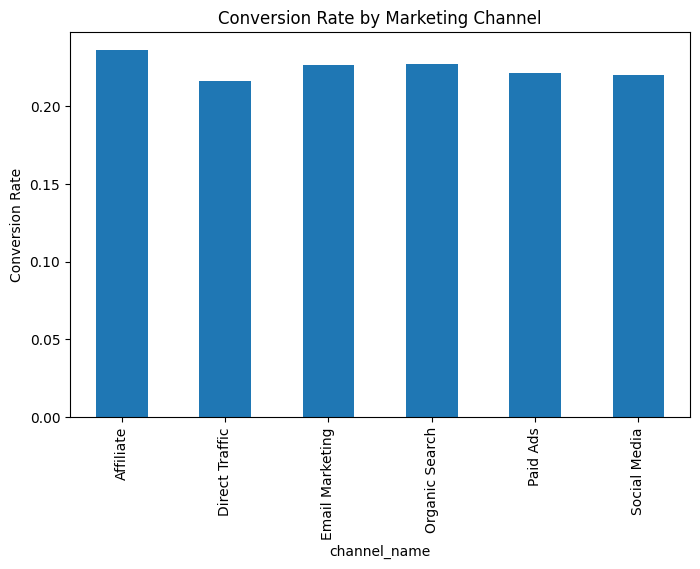

In [6]:
conversion = df.groupby('channel_name')['purchased'].mean()

conversion.plot(kind='bar', figsize=(8,5))
plt.title("Conversion Rate by Marketing Channel")
plt.ylabel("Conversion Rate")
plt.show()

REVENUE ANALYSIS

In [7]:
revenue = df.groupby('channel_name')['revenue'].sum()

revenue

channel_name
Affiliate          1820823.79
Direct Traffic     1599821.67
Email Marketing    1675463.47
Organic Search     1661328.76
Paid Ads           1646768.68
Social Media       1711962.69
Name: revenue, dtype: float64

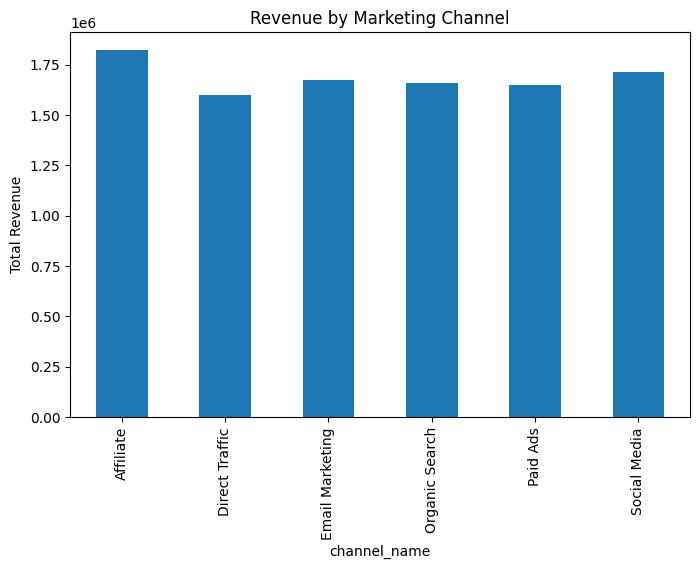

In [8]:
revenue.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Marketing Channel")
plt.ylabel("Total Revenue")
plt.show()

CART ABANDONMENT ANALYSIS

In [9]:
abandonment = df.groupby('channel_name')['cart_abandoned'].mean()

abandonment

channel_name
Affiliate          0.407460
Direct Traffic     0.418593
Email Marketing    0.419096
Organic Search     0.428359
Paid Ads           0.421002
Social Media       0.426069
Name: cart_abandoned, dtype: float64

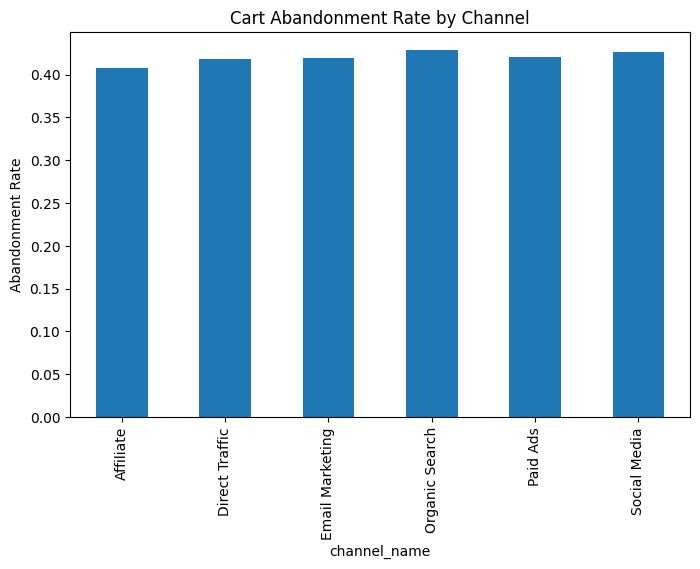

In [10]:
abandonment.plot(kind='bar', figsize=(8,5))
plt.title("Cart Abandonment Rate by Channel")
plt.ylabel("Abandonment Rate")
plt.show()

HEATMAP

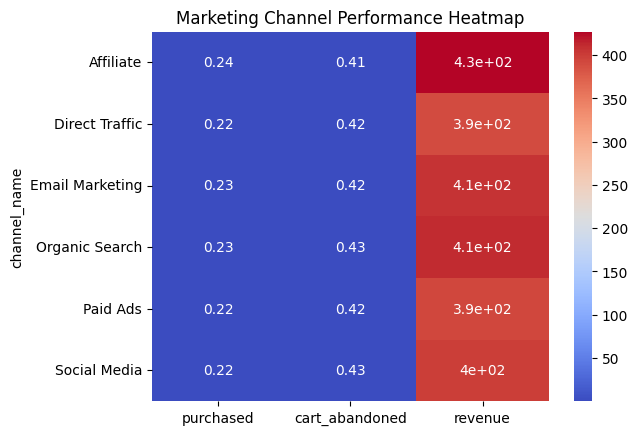

In [11]:
analysis_df = df.groupby('channel_name').agg({
    'purchased': 'mean',
    'cart_abandoned': 'mean',
    'revenue': 'mean'
})

sns.heatmap(analysis_df, annot=True, cmap='coolwarm')
plt.title("Marketing Channel Performance Heatmap")
plt.show()

FINAL INSIGHT CELL

In [12]:
best_channel = conversion.idxmax()
worst_channel = abandonment.idxmax()

print("Best Performing Channel:", best_channel)
print("Worst Channel (High Abandonment):", worst_channel)

Best Performing Channel: Affiliate
Worst Channel (High Abandonment): Organic Search


In [13]:
conversion.to_csv("../reports/marketing_conversion.csv")
revenue.to_csv("../reports/marketing_revenue.csv")
abandonment.to_csv("../reports/marketing_abandonment.csv")

## 📌 Key Insights

- Channel X has highest conversion rate  
- Channel Y generates highest revenue  
- Channel Z has highest abandonment rate  

## 📌 Business Recommendation

- Invest more in high-conversion channels  
- Optimize high-abandonment channels  